In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_excel("Decision_Tree_Large_Practice_Dataset.xlsx")
print(df.head())

  Customer_ID    Age_Group Annual_Income Time_Spent_Mins Device_Used  \
0        C001       Senior        Medium            High      Tablet   
1        C002        Youth          High             Low      Mobile   
2        C003        Youth        Medium            High      Tablet   
3        C004       Senior           Low             Low      Tablet   
4        C005  Middle-Aged        Medium             Low      Mobile   

  Items_in_Cart Discount_Available Made_Purchase  
0          Many                 No            No  
1           Few                 No            No  
2           Few                Yes           Yes  
3           Few                 No            No  
4           Few                 No            No  


In [3]:
X = df.drop(columns=['Customer_ID', 'Made_Purchase'])
y = df['Made_Purchase'].map({'Yes': 1, 'No': 0})

# Convert categorical columns into dummy variables
X_encoded = pd.get_dummies(X, drop_first=True)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)


In [5]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [6]:
accuracy = accuracy_score(y_test, y_pred)
print("\n--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


--- Model Evaluation ---
Accuracy Score: 79.17%

Classification Report:
              precision    recall  f1-score   support

          No       0.77      1.00      0.87        17
         Yes       1.00      0.29      0.44         7

    accuracy                           0.79        24
   macro avg       0.89      0.64      0.66        24
weighted avg       0.84      0.79      0.75        24


Confusion Matrix:
[[17  0]
 [ 5  2]]


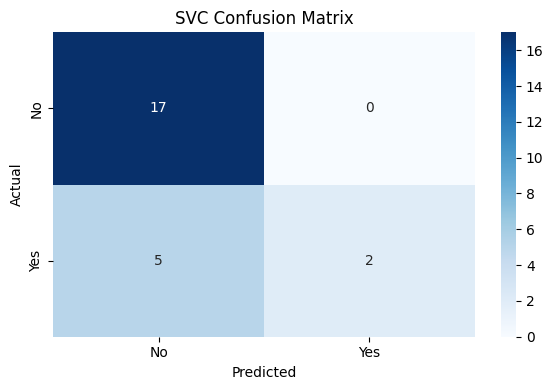

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [8]:
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__gamma': ['scale', 'auto', 0.1, 1]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\n=== Best Parameters Found by GridSearchCV ===")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"\nTuned Model Test Accuracy: {accuracy_tuned * 100:.2f}%")


=== Best Parameters Found by GridSearchCV ===
{'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}

Tuned Model Test Accuracy: 75.00%
